In [5]:
print("\nTask-3 :- Unveiling the Android App Market: Analyzing Google Play Store Data \n")


Task-3 :- Unveiling the Android App Market: Analyzing Google Play Store Data 



In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("apps.csv")
df.head(8)

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
5,5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5.6,"50,000+",Free,0,Everyone,Art & Design,"March 26, 2017",1,2.3 and up
6,6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,3.8,178,19.0,"50,000+",Free,0,Everyone,Art & Design,"April 26, 2018",1.1,4.0.3 and up
7,7,Infinite Painter,ART_AND_DESIGN,4.1,36815,29.0,"1,000,000+",Free,0,Everyone,Art & Design,"June 14, 2018",6.1.61.1,4.2 and up


In [9]:
df.shape

(9659, 14)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   object 
 7   Type            9659 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.0+ MB


In [11]:
df.isnull().sum()

Unnamed: 0           0
App                  0
Category             0
Rating            1463
Reviews              0
Size              1227
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

In [14]:
df.drop_duplicates(inplace=True)

df.ffill(inplace=True)

In [17]:
#Remove symbols
df['Installs'] = df['Installs'].astype(str)

df['Installs'] = df['Installs'].str.replace('+','', regex=False)

df['Installs'] = df['Installs'].str.replace(',','', regex=False)

df['Installs'] = df['Installs'].astype(int)

In [18]:
#Convert Price
df['Price'] = df['Price'].str.replace('$','')

df['Price'] = df['Price'].astype(float)

In [20]:
#Convert Reviews
df['Reviews'] = pd.to_numeric(df['Reviews'])

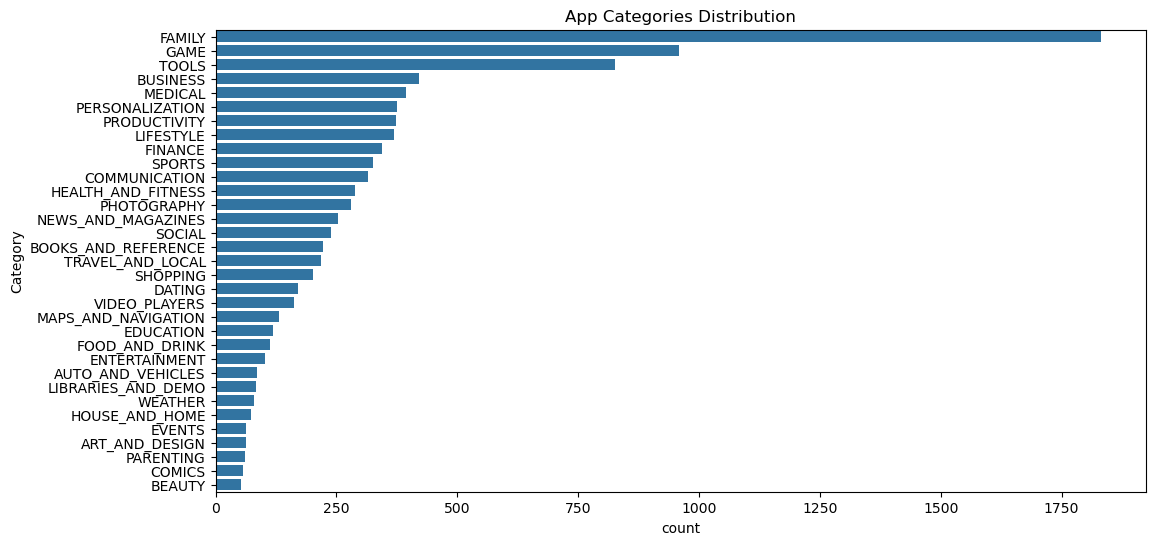

In [22]:
plt.figure(figsize=(12,6))

sns.countplot(y='Category',
              data=df,
              order=df['Category'].value_counts().index)
plt.title("App Categories Distribution")
plt.show()

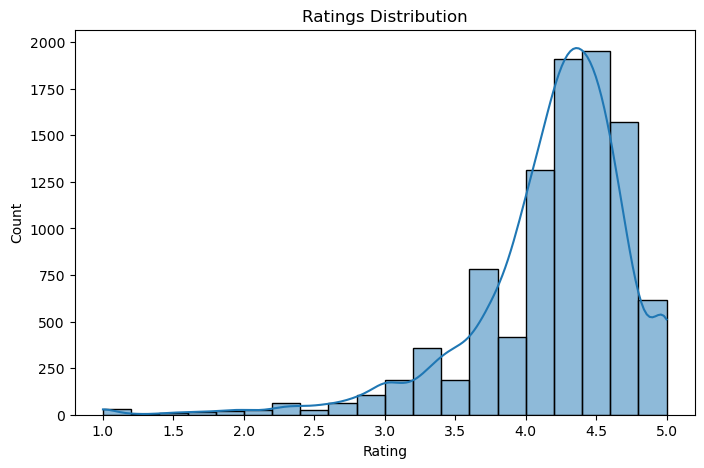

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['Rating'], bins=20, kde=True)
plt.title("Ratings Distribution")
plt.show()

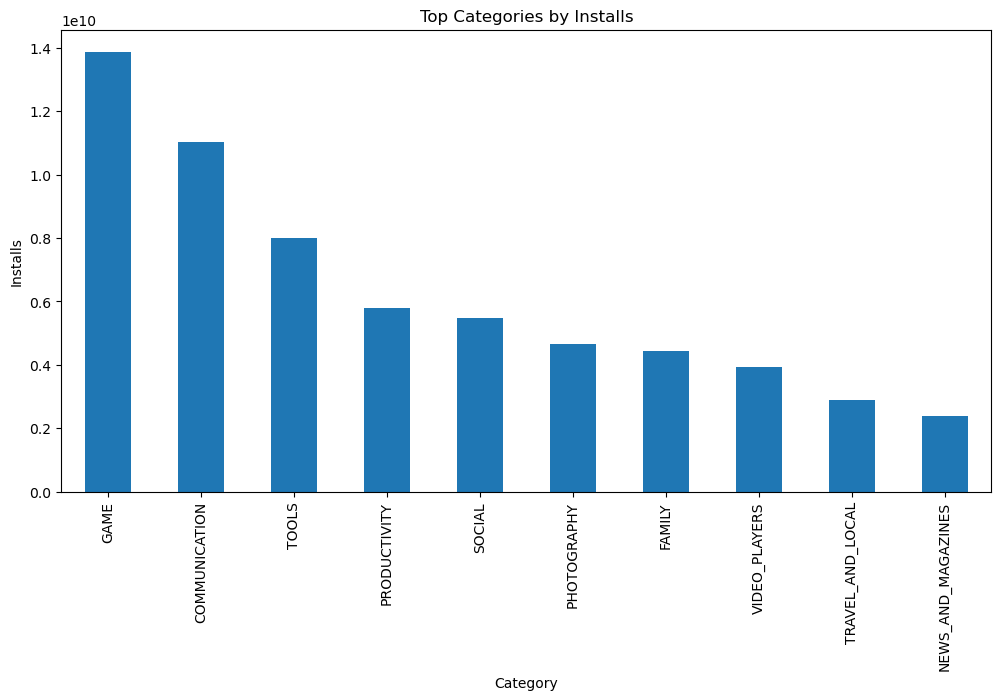

In [24]:
#Top Installed Catagories
top_installs = df.groupby('Category')['Installs'].sum().sort_values(ascending=False)
plt.figure(figsize=(12,6))
top_installs.head(10).plot(kind='bar')
plt.title("Top Categories by Installs")
plt.ylabel("Installs")
plt.show()

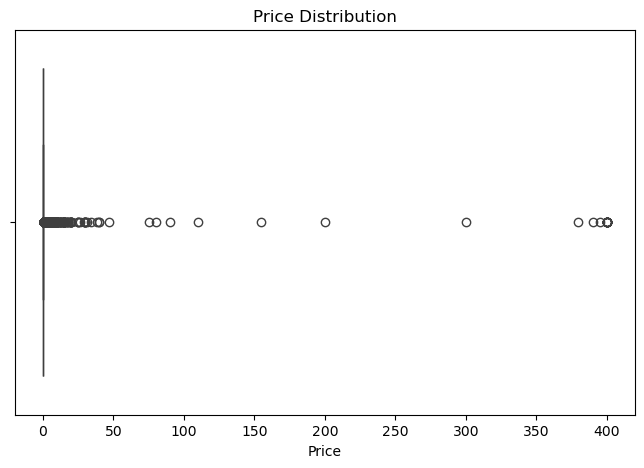

In [25]:
# Price Analysis
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Price'])
plt.title("Price Distribution")
plt.show()

In [27]:
#Size Analysis
# Replace text values with NaN
df['Size'] = df['Size'].replace('Varies with device', np.nan)

# Convert entire column to string first
df['Size'] = df['Size'].astype(str)

# Remove 'M'
df['Size'] = df['Size'].str.replace('M', '', regex=False)

# Remove 'k'
df['Size'] = df['Size'].str.replace('k', '', regex=False)

# Convert to numeric
df['Size'] = pd.to_numeric(df['Size'], errors='coerce')

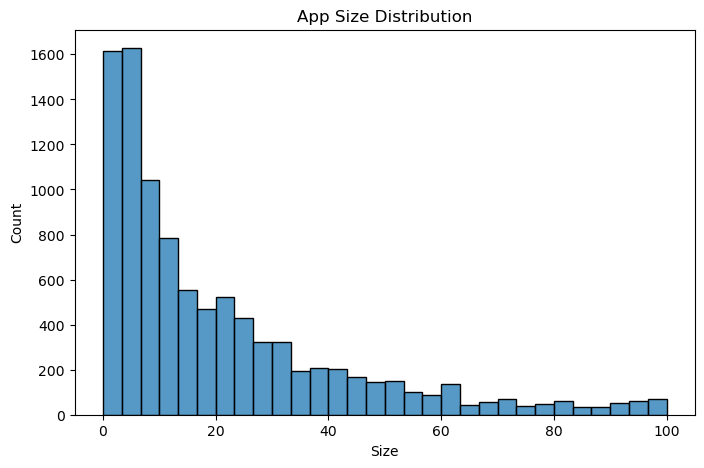

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(df['Size'], bins=30)
plt.title("App Size Distribution")
plt.show()

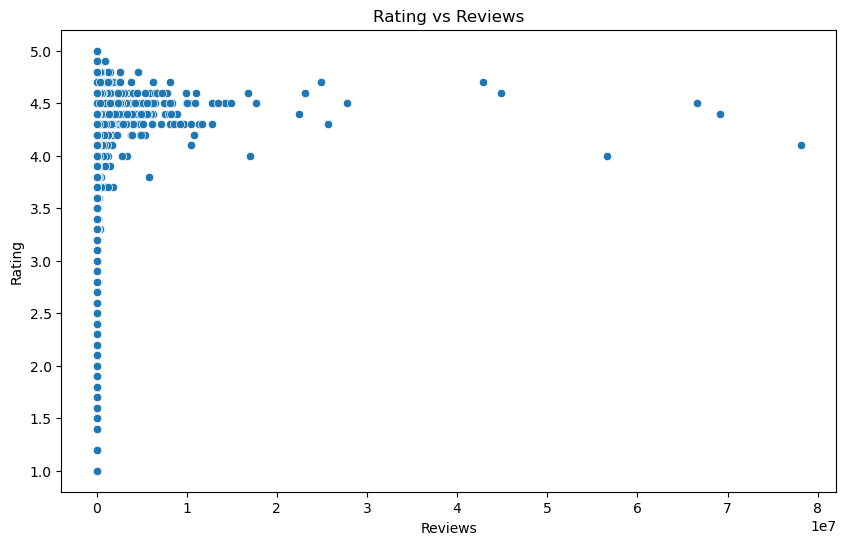

In [29]:
#Interactive Visualization
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Reviews',
    y='Rating',
    data=df
)
plt.title("Rating vs Reviews")
plt.show()

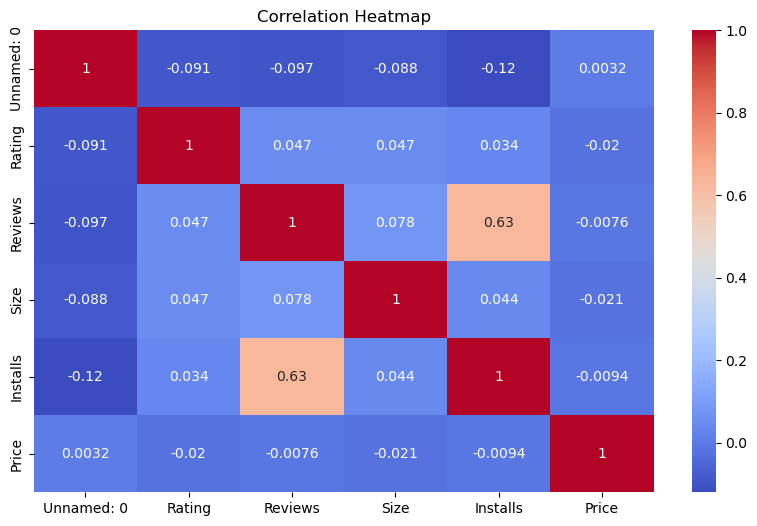

In [30]:
#Correlation Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()